# Task 4: Churn Prediction Model

## Step 1 : Import Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

## Step 2 : Load Dataset

In [4]:
df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

## Step 3 : Data Cleaning

In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df.dropna(inplace=True)

## Step 4 : Remove Customer ID

In [8]:
df.drop("customerID", axis=1, inplace=True)

## Step 5 : Encode Target Variable

In [9]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [10]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## Step 6 : One-Hot Encode Features

In [12]:
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

In [13]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## Step 7 : Separate Features and Target

In [14]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [15]:
print(X.shape)

print(y.shape)

(7032, 30)
(7032,)


## Step 8 : Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Let's verify

In [17]:
print(X_train.shape)

print(X_test.shape)

(5625, 30)
(1407, 30)


## Step 9 : Feature Scaling

In [19]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Step 10 : Train the Logistic Regression Model

In [21]:
# Create Logistic Regression Model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


- LogisticRegression() creates the model.
- random_state=42 ensures reproducible results.
- fit() trains the model using the training data.

## Step 11 : Make Predictions

- Predict customer churn on the test dataset.

In [22]:
# Predict class labels
y_pred = model.predict(X_test)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

## Step 12 : Model Accuracy

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 80.45 %


## Step 13 : Precision

In [24]:
precision = precision_score(y_test, y_pred)

print("Precision :", round(precision*100,2), "%")

Precision : 65.05 %


## Step 14 : Recall

In [25]:
recall = recall_score(y_test, y_pred)

print("Recall :", round(recall*100,2), "%")

Recall : 57.22 %


## Step 15 : F1 Score

In [26]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", round(f1*100,2), "%")

F1 Score : 60.88 %


## Step 16 : ROC-AUC Score

In [27]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC :", round(roc_auc,3))

ROC-AUC : 0.836


- A value close to 1 indicates better performance.

## Step 17 : Classification Report

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Step 18 : Confusion Matrix

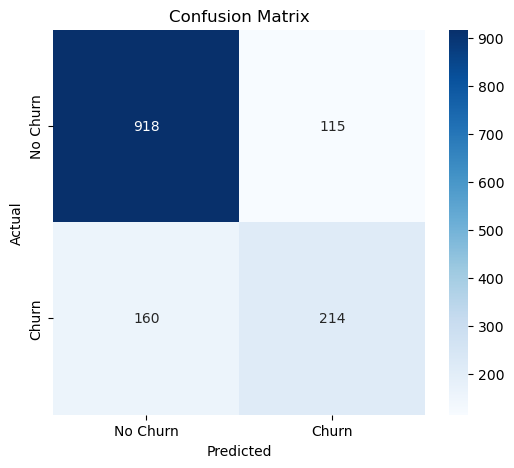

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

- The diagonal cells represent correct predictions.

## Step 19 : ROC Curve

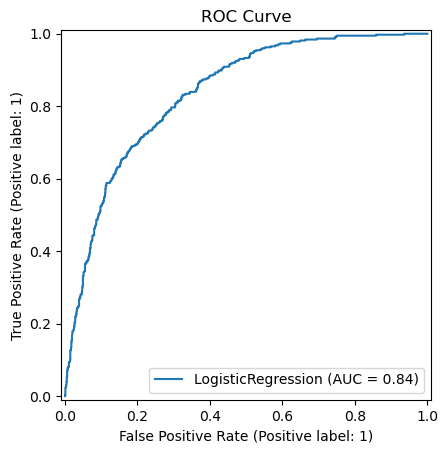

In [30]:
RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

- A curve closer to the top-left corner indicates better discrimination between churners and non-churners.

## Step 20 : Feature Importance

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

### Top Positive Coefficients

##### These features increase the likelihood of churn.

In [33]:
importance.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.121685
3,TotalCharges,0.641811
28,PaymentMethod_Electronic check,0.386286
21,StreamingTV_Yes,0.374880
9,MultipleLines_Yes,0.362680
23,StreamingMovies_Yes,0.347601
26,PaperlessBilling_Yes,0.290723
0,SeniorCitizen,0.195363
29,PaymentMethod_Mailed check,0.076969
17,DeviceProtection_Yes,0.073764


### Top Negative Coefficients

##### These features reduce the likelihood of churn.

In [35]:
importance.tail(10)

,Feature,Coefficient
20,StreamingTV_No internet service,-0.168056
8,MultipleLines_No phone service,-0.183234
6,Dependents_Yes,-0.231842
19,TechSupport_Yes,-0.329742
13,OnlineSecurity_Yes,-0.370820
2,MonthlyCharges,-0.445174
7,PhoneService_Yes,-0.522947
24,Contract_One year,-0.743489
25,Contract_Two year,-1.351225
1,tenure,-1.355817


## Step 21 : Visualize Feature Importance

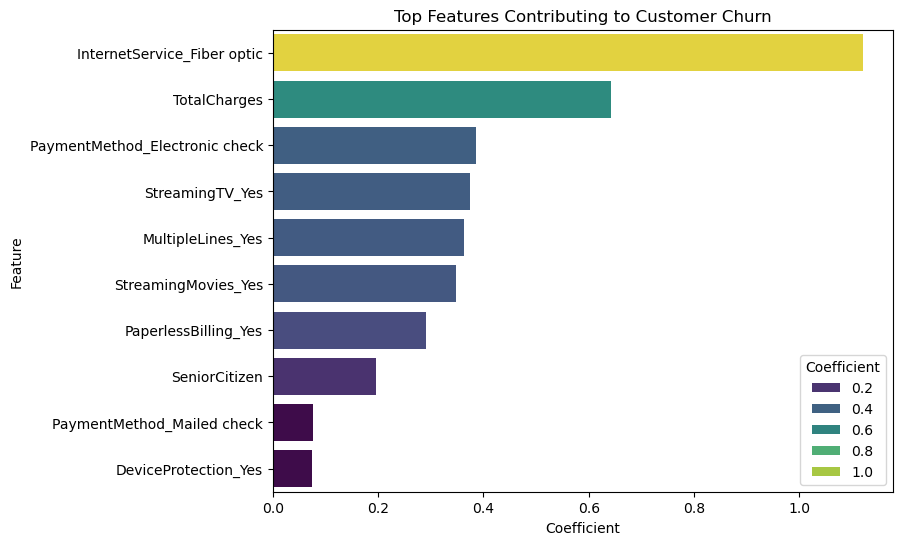

In [37]:
top_features = importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    hue = 'Coefficient',
    y="Feature",
    palette="viridis"
)

plt.title("Top Features Contributing to Customer Churn")

plt.show()

## Step 22 : Model Summary

- Create a small table summarizing the evaluation metrics.

In [39]:
results = pd.DataFrame({
    "Metric": ["Accuracy",
               "Precision",
               "Recall",
               "F1 Score",
               "ROC-AUC"],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.804549
1,Precision,0.650456
2,Recall,0.572193
3,F1 Score,0.608819
4,ROC-AUC,0.836071


## Step 23 : Final Conclusion

## Churn Prediction Model - Conclusion
- A Logistic Regression model was developed to predict customer churn.

### Model Performance

- Accuracy : 80.45 %
- Precision : 65.04 %
- Recall : 57.21 %
- F1 Score : 60.88 %
- ROC-AUC : 83.60 %

### Key Findings

- Customers with month-to-month contracts have a higher probability of churn.
- Customers with shorter tenure are more likely to leave.
- Higher monthly charges are associated with increased churn.
- Customers using electronic checks show a higher churn tendency.

Overall, the model provides reliable predictions and can help the company identify at-risk customers and implement proactive retention strategies.